## Quantum Inspire Cloud Connection
In this notebook we will establish a cloud connection to the QuTech Quantum Inspire cloud. Access is free. It is hard to run this notebook in the binder session, because you need to establish a connection between your device and the QI machine through your terminal. You do this by running: 

pip install quantuminspire

qi login

This will take you to the webpage to login.

In [23]:
#on top of what is in the requirements.txt, we are gonna need to install the QI qiskit plugin
#!pip qiskit_quantuminspire
from qiskit_quantuminspire.qi_provider import QIProvider

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
from qiskit.visualization import plot_bloch_multivector, plot_histogram

provider = QIProvider()
print(provider.backends())

[<qiskit_quantuminspire.qi_backend.QIBackend object at 0x219d712eb70 (name=QX emulator, id=1)>, <qiskit_quantuminspire.qi_backend.QIBackend object at 0x219d712d040 (name=Tuna-5, id=4)>, <qiskit_quantuminspire.qi_backend.QIBackend object at 0x219d820fd90 (name=Ry emulator, id=5)>, <qiskit_quantuminspire.qi_backend.QIBackend object at 0x219d716c750 (name=Tuna-9, id=6)>, <qiskit_quantuminspire.qi_backend.QIBackend object at 0x219d22207a0 (name=Tuna-17, id=7)>]


In [20]:
#choose backend from printed list above
backend = provider.get_backend("Tuna-9")

{'00': 505, '01': 479, '10': 526, '11': 490}


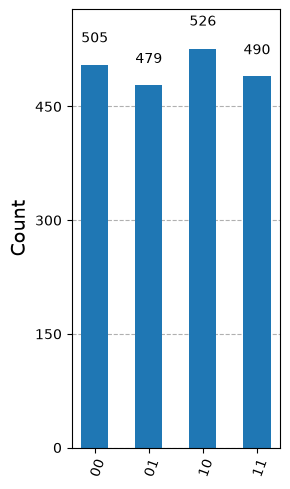

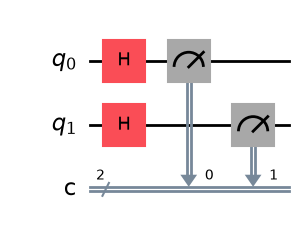

In [26]:
#make quantum circuit
q = QuantumRegister(2, 'q')
c = ClassicalRegister(2, 'c')
circuit = QuantumCircuit(q,c)
circuit.h(q)
circuit.measure(q,c)

compiled_qc = transpile(circuit, backend=backend)
results = backend.run(compiled_qc, shots=2000).result()
counts= results.get_counts()
print(counts)

#show counts
display(plot_histogram(counts,figsize=(3,5)))
#show circuit
display(circuit.draw(output='mpl'))